In [95]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [96]:
from pathlib import Path


cars_path = Path("cars_split.csv")
if not cars_path.exists():
    cars_path = Path("..") / "cars_split.csv"

df = pd.read_csv(cars_path)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car brand,car model
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet,chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick,skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth,satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc,rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford,torino


In [97]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
hp_median = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(hp_median)
print(f"Imputed 6 missing horsepower values with median = {hp_median}")

Imputed 6 missing horsepower values with median = 93.5


In [98]:
df['fuel_efficient'] = (df['mpg'] >= 23).astype(int)
label_counts = df['fuel_efficient'].value_counts()
print(f"\nTarget distribution: 0 (not efficient) = {label_counts[0]}, 1 (efficient) = {label_counts[1]}")


Target distribution: 0 (not efficient) = 197, 1 (efficient) = 201


In [99]:
NUMERIC_FEATURES = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year']
CATEGORICAL_FEATURES = ['origin', 'car brand']

df_encoded = pd.get_dummies(df, columns=CATEGORICAL_FEATURES, drop_first=True)


In [100]:
ohe_cols = [c for c in df_encoded.columns
            if c.startswith('origin_') or c.startswith('car brand_')]
feature_cols = NUMERIC_FEATURES + ohe_cols
 
X = df_encoded[feature_cols]
y = df_encoded['fuel_efficient']

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train = X_train.copy()
X_test  = X_test.copy()
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES]  = scaler.transform(X_test[NUMERIC_FEATURES])

Train: 318 | Test: 80


In [102]:
model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [103]:
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
 
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print("\n── Evaluation Metrics ──────────────────────────────")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Efficient (0)', 'Efficient (1)']))


── Evaluation Metrics ──────────────────────────────
  Accuracy  : 0.9500
  Precision : 0.9091
  Recall    : 1.0000
  F1 Score  : 0.9524
  ROC-AUC   : 0.9975

Full Classification Report:
                   precision    recall  f1-score   support

Not Efficient (0)       1.00      0.90      0.95        40
    Efficient (1)       0.91      1.00      0.95        40

         accuracy                           0.95        80
        macro avg       0.95      0.95      0.95        80
     weighted avg       0.95      0.95      0.95        80



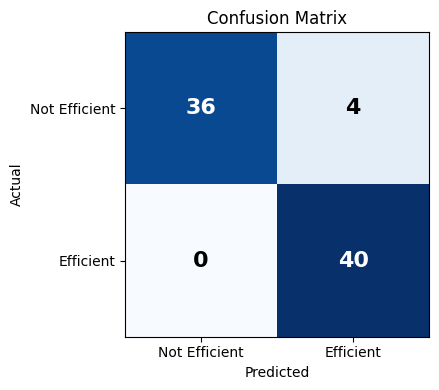

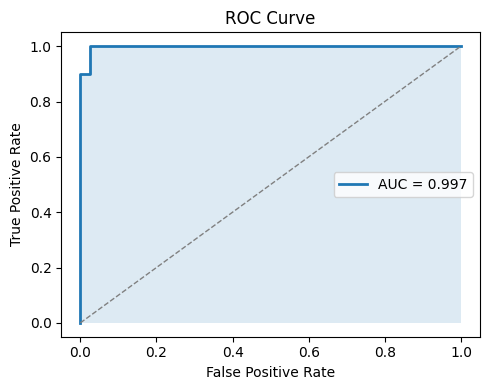

Saved confusion_matrix.png and roc_curve.png


In [105]:
# Confusion Matrix
from sklearn.metrics import roc_curve

fig1, ax1 = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
im = ax1.imshow(cm, cmap='Blues')
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(['Not Efficient', 'Efficient'])
ax1.set_yticklabels(['Not Efficient', 'Efficient'])
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=16, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')
fig1.tight_layout()
fig1.savefig('../article/confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
fig2, ax2 = plt.subplots(figsize=(5, 4))
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax2.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
ax2.plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax2.fill_between(fpr, tpr, alpha=0.15)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()
fig2.tight_layout()
fig2.savefig('../article/roc_curve.png', dpi=150)
plt.show()

print("Saved confusion_matrix.png and roc_curve.png")